**Libraries**

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

**Loading image and Labels**

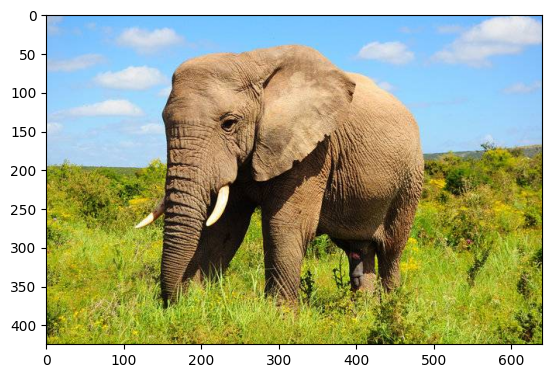

In [2]:
image = cv2.imread("elephant.jpg")
plt.imshow(image[...,::-1])

In [6]:
#Load labels from txt file (ImageNet labels)
rows = open("./model/synset_words.txt").read().strip().split("\n")
classes = [r[r.find(" ") + 1:].split(",")[0] for r in rows]
print(classes[1])

goldfish


**Binary Large Object**

In [7]:
#Lets build a blob: a 4D preprocessed input tensor for large binary data such as images -> image value + batch size + color channels + h and w
# blobFromImage -> 
#   scalefactor: multiplies each pixel value, multiplies each pixel value
#   size: the image will be resized to 224x224 pixels (height, width), which is the standard input size for models like VGG, ResNet, etc.
#   Mean subtraction values:  These are common values used for models trained on ImageNet — they help normalize the input data by centering the pixel values.
blob = cv2.dnn.blobFromImage(image,
                            scalefactor=  1, 
                            size= (224, 224),
                            mean= (104, 117, 123))
blob.shape

(1, 3, 224, 224)

**Build our network using pre-trained model's weight**

In [10]:
#Read network weights and architecture for pre-trained models
net = cv2.dnn.readNetFromCaffe("./model/bvlc_googlenet.prototxt", "./model/bvlc_googlenet.caffemodel")

#lets introduce our input to the network
net.setInput(blob)

**Prediction in OpenCV using Google Net**

In [11]:
predictions = net.forward()
print('predictions: ', predictions)
print('predictions shape: ', predictions.shape )

indexes = np.argmax(predictions)
print('predicted class: ', classes[indexes])

#lets show the winner classes with detection probability
indexes = np.argsort(predictions[0])[::-1][:3]
for index in indexes:
    print("{}'th predicted class: {}, {:.2f}%".format(index,classes[index], predictions[0][index]*100))

predictions:  [[4.79842477e-09 2.16395721e-10 2.64430457e-11 2.66753231e-10
  3.71258996e-10 2.32348873e-09 3.25656968e-09 3.55082436e-10
  1.34665404e-10 2.81131451e-09 2.67733447e-10 4.04470180e-10
  1.93187288e-09 6.76138978e-10 2.65081512e-10 2.58605620e-11
  3.46091711e-10 1.18273974e-10 3.17265728e-11 9.06547545e-11
  4.34102865e-10 5.14152143e-09 1.14598619e-09 1.26517907e-08
  9.05887698e-10 2.53455923e-10 3.61568192e-10 7.33517483e-11
  1.78727935e-10 1.41806733e-10 1.42173981e-10 2.24813890e-10
  2.04444878e-10 1.12959098e-09 8.68704719e-10 2.08668260e-09
  5.47905321e-09 4.15035256e-10 3.06360104e-10 5.62989975e-08
  9.43502609e-10 1.79795467e-09 3.66865816e-10 2.30572077e-08
  1.88048133e-09 1.10012319e-08 4.41144454e-09 3.38319772e-09
  1.16722504e-06 4.79176698e-09 6.52081189e-09 1.23943471e-06
  1.13204757e-09 6.84285295e-10 1.45881138e-08 3.67497532e-10
  4.78328099e-10 2.33185971e-11 5.64702862e-09 1.97180175e-10
  4.93860286e-10 2.30471686e-09 4.82274887e-09 1.2443104

## GoogleNet

 GoogLeNet, also known as Inception v1, is a deep convolutional neural network developed by Google that won the ImageNet Large-Scale Visual Recognition Challenge in 2014. It's notable for its innovative use of "Inception modules". These modules allow the network to process information using multiple filter sizes (1x1, 3x3, and 5x5) in parallel within a single layer, capturing features at different scales more efficiently. 
